## **Problema de Negocio a Resolver:**

Se busca desarrollar un sistema de predicción de precios de pasajes aéreos para una plataforma de reservas de vuelos. El objetivo principal es predecir con la mayor precisión posible el precio final de un boleto de avión basándose en características históricas de vuelos, con el fin de:

-Optimizar estrategias de precios dinámicos para las aerolíneas

-Ofrecer a los usuarios alertas sobre mejores momentos para comprar

-Maximizar ingresos mediante la identificación de patrones de precios

-Mejorar la competitividad de la plataforma en el mercado

### **Cómo se va a hacer esto:**

-Metodología CRISP-DM (Cross-Industry Standard Process for Data Mining):

-Comprensión del Negocio: Analizar necesidades de aerolíneas y usuarios

-Comprensión de los Datos: Explorar dataset de ~90,000 registros históricos de vuelos

-Preparación de Datos: Limpieza, transformación y feature engineering

-Modelado: Implementación y comparación de múltiples algoritmos de ML

-Evaluación: Validación de modelos con métricas de regresión


### **Tareas Específicas a Realizar:**

Preprocesamiento de Datos:

-Limpieza de valores nulos en variables críticas (precio, horarios)

-Transformación de variables temporales (fecha, hora de salida/llegada)

-Codificación de variables categóricas (aerolínea, origen, destino, tipo de escala)

-Extracción de características de tiempo de vuelo (duración en horas/minutos)

-Estandarización/normalización de variables numéricas

### **Feature Engineering:**


-Codificación one-hot para aerolíneas y rutas

-Extracción de componentes de tiempo (hora, minuto de vuelos)


### ***Modelado Predictivo:**

Implementación de 3 modelos de regresión:

1) Regresión Lineal

2) Random Forest Regressor (para capturar no linealidades)

3) Árbol de decisión 

Se optimizarán a través de GridSearch y se realizará la comparación de las métricas MAE, RMSE, R².

La variable a predecir es el precio del boleto de avion lo que lo convierte en un problema de regresión, ya que es un valor continuo.

Con esto se espera reducir el error de predicción de precios en al menos 15-20%, identificar patrones estacionales de demanda, poder recomendar al usuario mejores oportunidades de precios, incrementar la cantidad de reservas de pasajes.


In [1]:
#Librerias Básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Selección de Modelos 
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelos
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metricas para problemas de regresión
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
#cargando dataset de business
df_b = pd.read_excel('business.xlsx')

# Ver primeras filas
print("Primeras 5 filas del dataset:")
display(df_b.head())

# Información: tipos de dato y valores nulos
print("\nInformación del dataset:")
df_b.info()

Primeras 5 filas del dataset:


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        93487 non-null  datetime64[ns]
 1   airline     93487 non-null  object        
 2   ch_code     93487 non-null  object        
 3   num_code    93487 non-null  int64         
 4   dep_time    93487 non-null  object        
 5   from        93487 non-null  object        
 6   time_taken  93487 non-null  object        
 7   stop        93487 non-null  object        
 8   arr_time    93487 non-null  object        
 9   to          93487 non-null  object        
 10  price       93487 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 7.8+ MB


In [3]:
df_e = pd.read_excel('economy.xlsx')

# Ver primeras filas
print("Primeras 5 filas del dataset:")
display(df_e.head())

# Información: tipos de dato y valores nulos
print("\nInformación del dataset:")
df_e.info()

Primeras 5 filas del dataset:


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,02h 10m,non-stop,21:05:00,Mumbai,5953
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,02h 20m,non-stop,08:40:00,Mumbai,5953
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,02h 10m,non-stop,06:35:00,Mumbai,5956
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,02h 15m,non-stop,12:35:00,Mumbai,5955
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,02h 20m,non-stop,11:10:00,Mumbai,5955



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        206774 non-null  datetime64[ns]
 1   airline     206774 non-null  object        
 2   ch_code     206774 non-null  object        
 3   num_code    206774 non-null  int64         
 4   dep_time    206774 non-null  object        
 5   from        206774 non-null  object        
 6   time_taken  206774 non-null  object        
 7   stop        206774 non-null  object        
 8   arr_time    206774 non-null  object        
 9   to          206774 non-null  object        
 10  price       206774 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 17.4+ MB


# **No hay nulos en ninguno de los dos dataset**

# **Distribucion de los precios Economy**

In [4]:
# Estadisticos descriptivo de la variable objetivo
df_e['price'].describe().round(2)

count    206774.00
mean       6571.19
std        3743.44
min        1105.00
25%        4173.00
50%        5772.00
75%        7746.00
max       42349.00
Name: price, dtype: float64

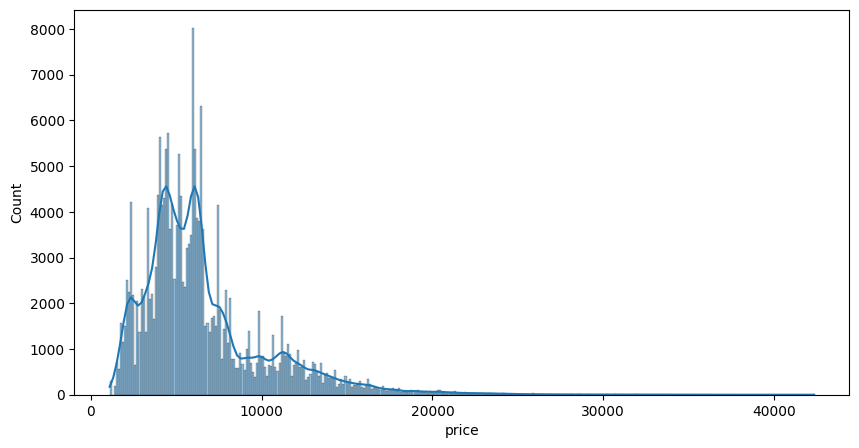

In [5]:
# distribucion de la variable objetivo
plt.figure(figsize=(10, 5))
sns.histplot(df_e['price'], kde=True);

# **Distribucion de los precios Business**

In [6]:
#transformacion variable object a numerico
df_b['price'] = pd.to_numeric(df_b['price'], errors = 'coerce' )

# Estadisticos descriptivo de la variable objetivo
df_b['price'].describe().round(2)

count    93379.00
mean     52478.99
std      12850.79
min      12000.00
25%      45185.00
50%      53164.00
75%      60396.00
max      99680.00
Name: price, dtype: float64

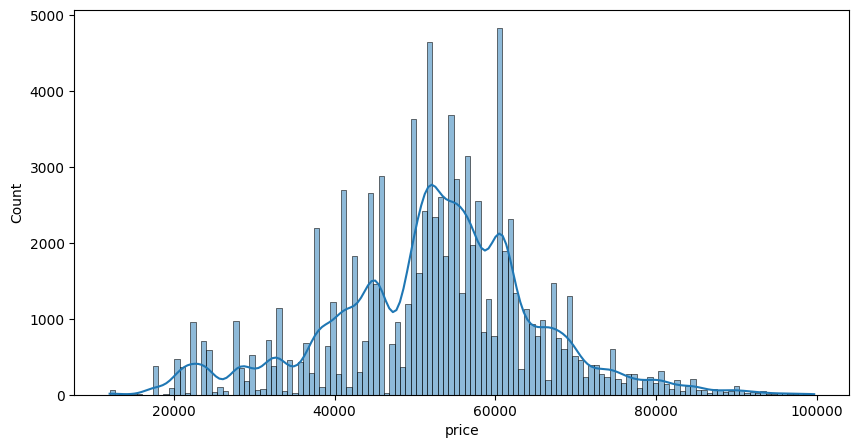

In [7]:
# distribucion de la variable objetivo
plt.figure(figsize=(10, 5))
sns.histplot(df_b['price'], kde=True);

## Transformacion de los dataset

#### Funcion para borrar columnas y transformar dataset

In [8]:
def drop_col(data,col):
    data.drop(col,axis=1,inplace=True)

def trans_df(df):
    
    # Variabe stop, se extrae solo los valores representativos
    df['stop'] = df['stop'].str.extract(r'^([\w\+-]+)')
    #se aplica a la variable la tecnica de codificacion label encoder
    le = preprocessing.LabelEncoder()
    df['stop'] = le.fit_transform(df['stop'])
    
    #Trabsformacio variable date, se extraera el dia y el mes
    df['date_day'] = pd.to_datetime(df.date, format="%d/%m/%Y").dt.day  
    df['date_month'] = pd.to_datetime(df.date, format="%d/%m/%Y").dt.month 
    #Se elimina columna date
    drop_col(df,'date')   
    
    #Trabsformacio variable dep_time y arr_time, se extraera la hora y los minutos
    df['dep_time_hour'] = pd.to_datetime(df['dep_time'], format='%H:%M:%S').dt.hour
    df['dep_time_min'] = pd.to_datetime(df['dep_time'], format='%H:%M:%S').dt.minute
    # Ya podemos eliminar la columna 'Dep_Time'
    drop_col(df,'dep_time')

    #Trabsformacio variable dep_time y arr_time, se extraera la hora y los minutos
    df["arr_time_hour"] = pd.to_datetime(df["arr_time"], format='%H:%M:%S').dt.hour
    df["arr_time_min"] = pd.to_datetime(df["arr_time"], format='%H:%M:%S').dt.minute
    # Ya podemos eliminar la columna 'arr_time' 
    drop_col(df,'arr_time')

    # 'Duration' Representa el tiempo que le toma al avión llegar a su destino.  39:41
    # Es diferente las variables 'Departure Time' y 'Arrival time'.
    # Primero tomamos todos los datos de la duración en una lista, y lo sobreescribimos, separando la hora de los minutos 39:40
    # Seguimos de esta manera ya que a diferencia de la columna de arriba 'datetime' acá tenemos horas y minutos, en lugar de 
    # día, mes, año; aunque de manera equivalente podríamos adaptar el código de arriba.

    # Asignando y convirtiendo la columna'Duration' en una lista
    duration = list(df['time_taken'])
    duration_hours = []
    duration_mins = []

    for i in range(len(duration)):
        current = str(duration[i]).strip()
    
        # Caso especial para valores como '1.03h m' que esta en la fila 96486
        if "." in current and "h" in current:
            # Extraer la parte numérica antes de 'h'
            hours_part = current.split("h")[0].strip()
            # Convertir decimal a horas y minutos
            total_hours = float(hours_part)
            hours = int(total_hours)
            minutes = int(round((total_hours - hours) * 60))
        
            duration_hours.append(hours)
            duration_mins.append(minutes)
            continue
    
        # Observar si 'Duration' contiene solo horas y minutos
        if len(current.split()) != 2: 
            if "h" in current:
                current = current.strip() + " 0m"
            else:
                current = "0h " + current
    
        # Extraer horas
        hours_part = current.split("h")[0].strip()
        hours = int(hours_part) if hours_part.isdigit() else 0
        duration_hours.append(hours)
    
        # Extraer minutos
        mins_part = current.split("m")[0].split()[-1]
        mins = int(mins_part) if mins_part.isdigit() else 0
        duration_mins.append(mins)

    # Agregar al DataFrame
    df['duration_hours'] = duration_hours
    df['duration_mins'] = duration_mins

    #se elimina columna time_taken
    drop_col(df,'time_taken')

In [9]:
# se aplica la transformacion correspondiente a las variables
trans_df(df_e)
trans_df(df_b)

In [10]:
df_e.head()

,airline,ch_code,num_code,from,stop,to,price,date_day,date_month,dep_time_hour,dep_time_min,arr_time_hour,arr_time_min,duration_hours,duration_mins
0,SpiceJet,SG,8709,Delhi,2,Mumbai,5953,11,2,18,55,21,5,2,10
1,SpiceJet,SG,8157,Delhi,2,Mumbai,5953,11,2,6,20,8,40,2,20
2,AirAsia,I5,764,Delhi,2,Mumbai,5956,11,2,4,25,6,35,2,10
3,Vistara,UK,995,Delhi,2,Mumbai,5955,11,2,10,20,12,35,2,15
4,Vistara,UK,963,Delhi,2,Mumbai,5955,11,2,8,50,11,10,2,20


In [11]:
df_b.head()

,airline,ch_code,num_code,from,stop,to,price,date_day,date_month,dep_time_hour,dep_time_min,arr_time_hour,arr_time_min,duration_hours,duration_mins
0,Air India,AI,868,Delhi,2,Mumbai,25612.0,11,2,18,0,20,0,2,0
1,Air India,AI,624,Delhi,2,Mumbai,25612.0,11,2,19,0,21,15,2,15
2,Air India,AI,531,Delhi,0,Mumbai,42220.0,11,2,20,0,20,45,24,45
3,Air India,AI,839,Delhi,0,Mumbai,44450.0,11,2,21,25,23,55,26,30
4,Air India,AI,544,Delhi,0,Mumbai,46690.0,11,2,17,15,23,55,6,40


## Revisamos nuevamente los nulos y Análisis estadistico descriptivo

In [12]:
df_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   airline         206774 non-null  object
 1   ch_code         206774 non-null  object
 2   num_code        206774 non-null  int64 
 3   from            206774 non-null  object
 4   stop            206774 non-null  int64 
 5   to              206774 non-null  object
 6   price           206774 non-null  int64 
 7   date_day        206774 non-null  int32 
 8   date_month      206774 non-null  int32 
 9   dep_time_hour   206774 non-null  int32 
 10  dep_time_min    206774 non-null  int32 
 11  arr_time_hour   206774 non-null  int32 
 12  arr_time_min    206774 non-null  int32 
 13  duration_hours  206774 non-null  int64 
 14  duration_mins   206774 non-null  int64 
dtypes: int32(6), int64(5), object(4)
memory usage: 18.9+ MB


In [13]:
df_e.describe()

,num_code,stop,price,date_day,date_month,dep_time_hour,dep_time_min,arr_time_hour,arr_time_min,duration_hours,duration_mins
count,206774.000000,206774.000000,206774.000000,206774.000000,206774.000000,206774.000000,206774.000000,206774.000000,206774.000000,206774.000000,206774.00000
mean,1706.096714,0.329292,6571.190701,17.380754,2.669373,12.844545,26.855480,15.036151,28.987832,11.099795,26.75390
std,2320.463721,0.700805,3743.442838,8.104344,0.470440,5.359420,17.783376,6.230898,18.254305,7.246695,17.37248
min,101.000000,0.000000,1105.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,588.000000,0.000000,4173.000000,12.000000,2.000000,8.000000,10.000000,10.000000,15.000000,6.000000,10.00000
50%,818.000000,0.000000,5772.000000,18.000000,3.000000,12.000000,30.000000,17.000000,30.000000,10.000000,25.00000
75%,960.000000,0.000000,7746.000000,24.000000,3.000000,18.000000,45.000000,20.000000,45.000000,15.000000,40.00000
max,9991.000000,2.000000,42349.000000,31.000000,3.000000,23.000000,55.000000,23.000000,59.000000,49.000000,59.00000


In [14]:
df_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   airline         93487 non-null  object 
 1   ch_code         93487 non-null  object 
 2   num_code        93487 non-null  int64  
 3   from            93487 non-null  object 
 4   stop            93487 non-null  int64  
 5   to              93487 non-null  object 
 6   price           93379 non-null  float64
 7   date_day        93487 non-null  int32  
 8   date_month      93487 non-null  int32  
 9   dep_time_hour   93487 non-null  int32  
 10  dep_time_min    93487 non-null  int32  
 11  arr_time_hour   93487 non-null  int32  
 12  arr_time_min    93487 non-null  int32  
 13  duration_hours  93487 non-null  int64  
 14  duration_mins   93487 non-null  int64  
dtypes: float64(1), int32(6), int64(4), object(4)
memory usage: 8.6+ MB


In [15]:
# Eliminar nulos de 'price'
df_b = df_b.dropna(subset=['price'])

In [16]:
df_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93379 entries, 0 to 93486
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   airline         93379 non-null  object 
 1   ch_code         93379 non-null  object 
 2   num_code        93379 non-null  int64  
 3   from            93379 non-null  object 
 4   stop            93379 non-null  int64  
 5   to              93379 non-null  object 
 6   price           93379 non-null  float64
 7   date_day        93379 non-null  int32  
 8   date_month      93379 non-null  int32  
 9   dep_time_hour   93379 non-null  int32  
 10  dep_time_min    93379 non-null  int32  
 11  arr_time_hour   93379 non-null  int32  
 12  arr_time_min    93379 non-null  int32  
 13  duration_hours  93379 non-null  int64  
 14  duration_mins   93379 non-null  int64  
dtypes: float64(1), int32(6), int64(4), object(4)
memory usage: 9.3+ MB


In [17]:
df_b.describe()

,num_code,stop,price,date_day,date_month,dep_time_hour,dep_time_min,arr_time_hour,arr_time_min,duration_hours,duration_mins
count,93379.000000,93379.000000,93379.000000,93379.000000,93379.000000,93379.000000,93379.000000,93379.000000,93379.000000,93379.000000,93379.000000
mean,780.001842,0.184849,52478.988220,17.395699,2.655940,13.291415,27.375802,15.685711,30.581822,13.269247,26.026569
std,147.666275,0.569397,12850.787066,8.008611,0.475063,5.358840,17.708071,5.604917,19.179358,6.862192,17.292939
min,401.000000,0.000000,12000.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,706.000000,0.000000,45185.000000,12.000000,2.000000,8.000000,10.000000,11.000000,15.000000,8.000000,10.000000
50%,820.000000,0.000000,53164.000000,18.000000,3.000000,13.000000,30.000000,17.000000,35.000000,13.000000,25.000000
75%,874.000000,0.000000,60396.000000,24.000000,3.000000,19.000000,45.000000,20.000000,50.000000,17.000000,40.000000
max,996.000000,2.000000,99680.000000,31.000000,3.000000,23.000000,55.000000,23.000000,55.000000,47.000000,55.000000


## Funcion para graficar variables

In [18]:
def grafico_variables(columna):
    # Crear figura con 2 subplots lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Encontrar max y min de precio
    y_min = min(df_e['price'].min(), df_b['price'].min())
    y_max = max(df_e['price'].max(), df_b['price'].max())

    # Primer gráfico: df_e
    sns.boxplot(x=columna, y='price', 
                data=df_e.sort_values('price', ascending=False),
                ax=axes[0])
    axes[0].set_title(f'{columna} vs Precio Economy', fontsize=14, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_ylim(y_min, y_max)

    # Segundo gráfico: df_b
    sns.boxplot(x=columna, y='price',
                data=df_b.sort_values('price', ascending=False),
                ax=axes[1])
    axes[1].set_title(f'{columna} vs Precio Business', fontsize=14, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylim(y_min, y_max)
    
    # Ajustar layout
    plt.tight_layout()
    plt.show()
                      

## Análisis del precio por Aerolínea

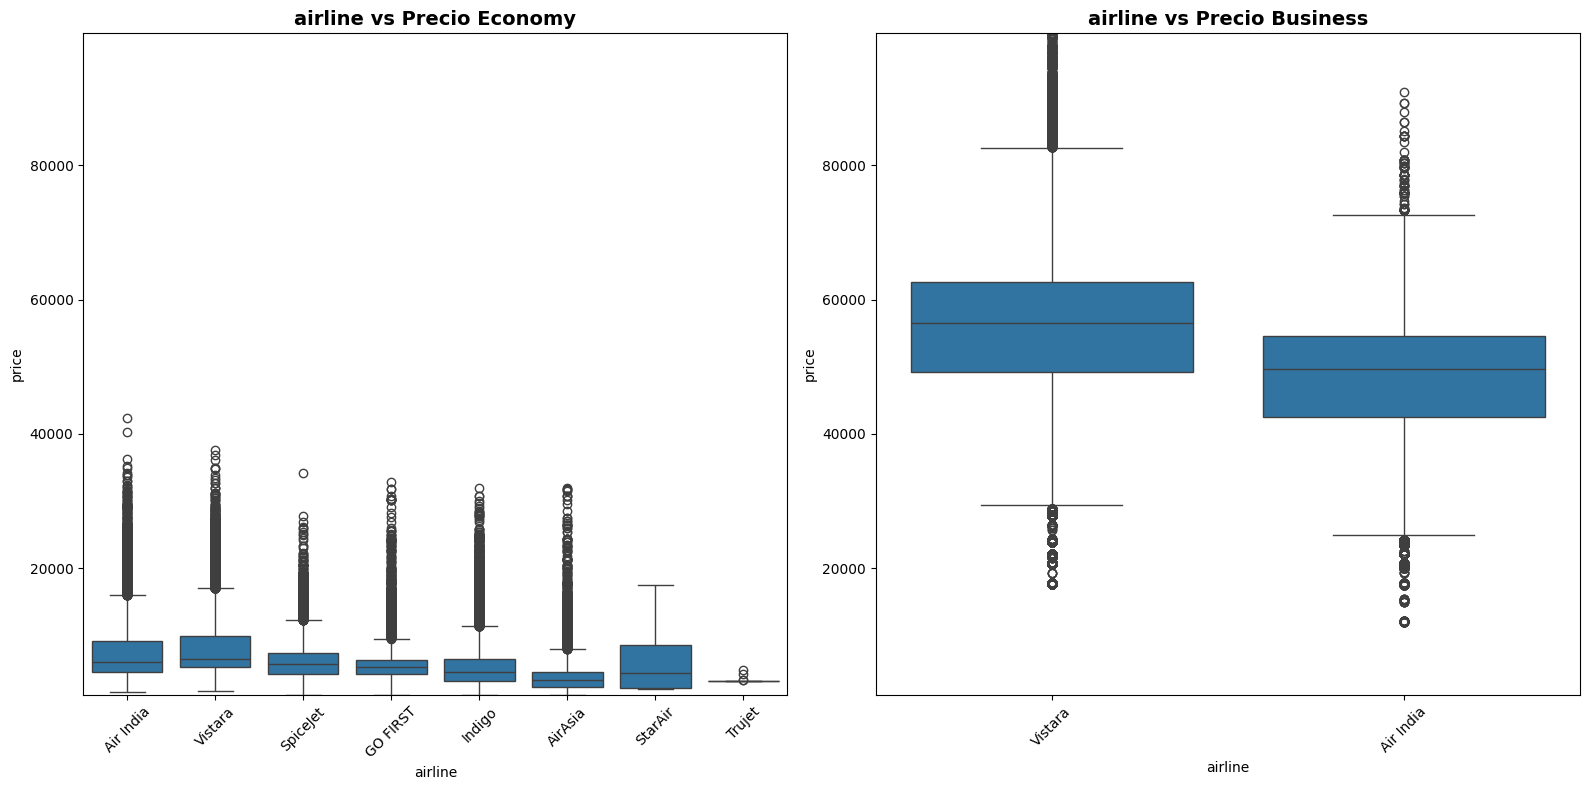

In [19]:
grafico_variables('airline')

En dataset de economy todas las aerolineas parecieran tener una mediana similar, pero todos poseen hartos outliers de precios altos. Mientras que en business, la aeorilinea Vistara tiene una mayor mediana que Air India. Los precios en Business son claramente superiores.

In [20]:
df_e['airline'].value_counts()

airline
Vistara      67270
Air India    47996
Indigo       43120
GO FIRST     23177
AirAsia      16098
SpiceJet      9011
StarAir         61
Trujet          41
Name: count, dtype: int64

In [21]:
df_b['airline'].value_counts()

airline
Vistara      60481
Air India    32898
Name: count, dtype: int64

## Análisis del precio por lugar de origen(from)

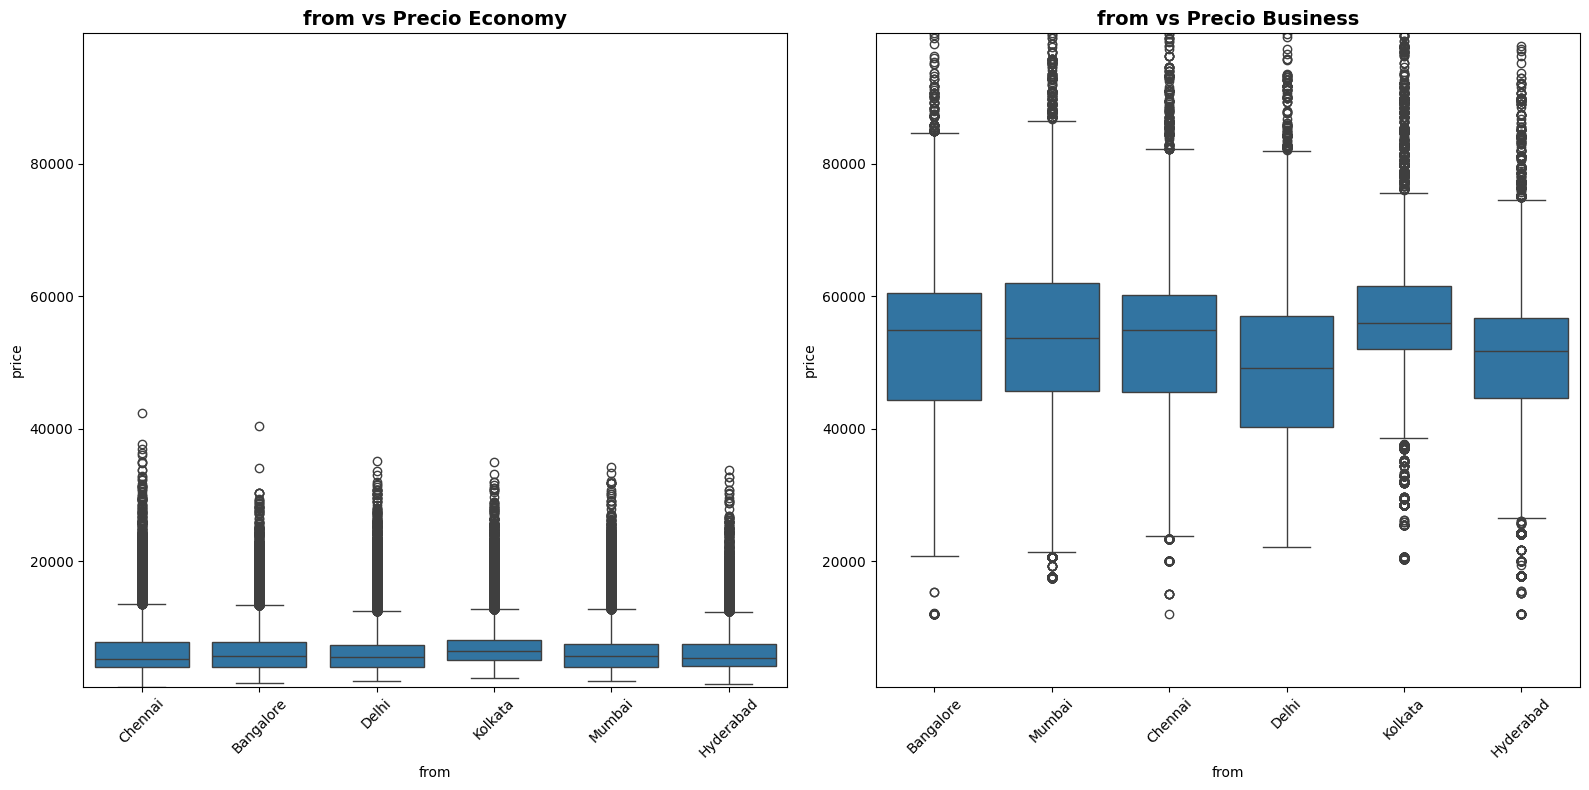

In [22]:
grafico_variables('from')

Sin importar el lugar de origen, los valores de los pasajes son similares en Economy y Business

In [23]:
df_e['from'].value_counts()

from
Delhi        43029
Mumbai       41045
Bangalore    35665
Kolkata      32874
Hyderabad    27990
Chennai      26171
Name: count, dtype: int64

In [24]:
df_b['from'].value_counts()

from
Mumbai       19835
Delhi        18291
Bangalore    16437
Kolkata      13439
Hyderabad    12868
Chennai      12509
Name: count, dtype: int64

### Análisis de los precios agrupados por lugar de llegada

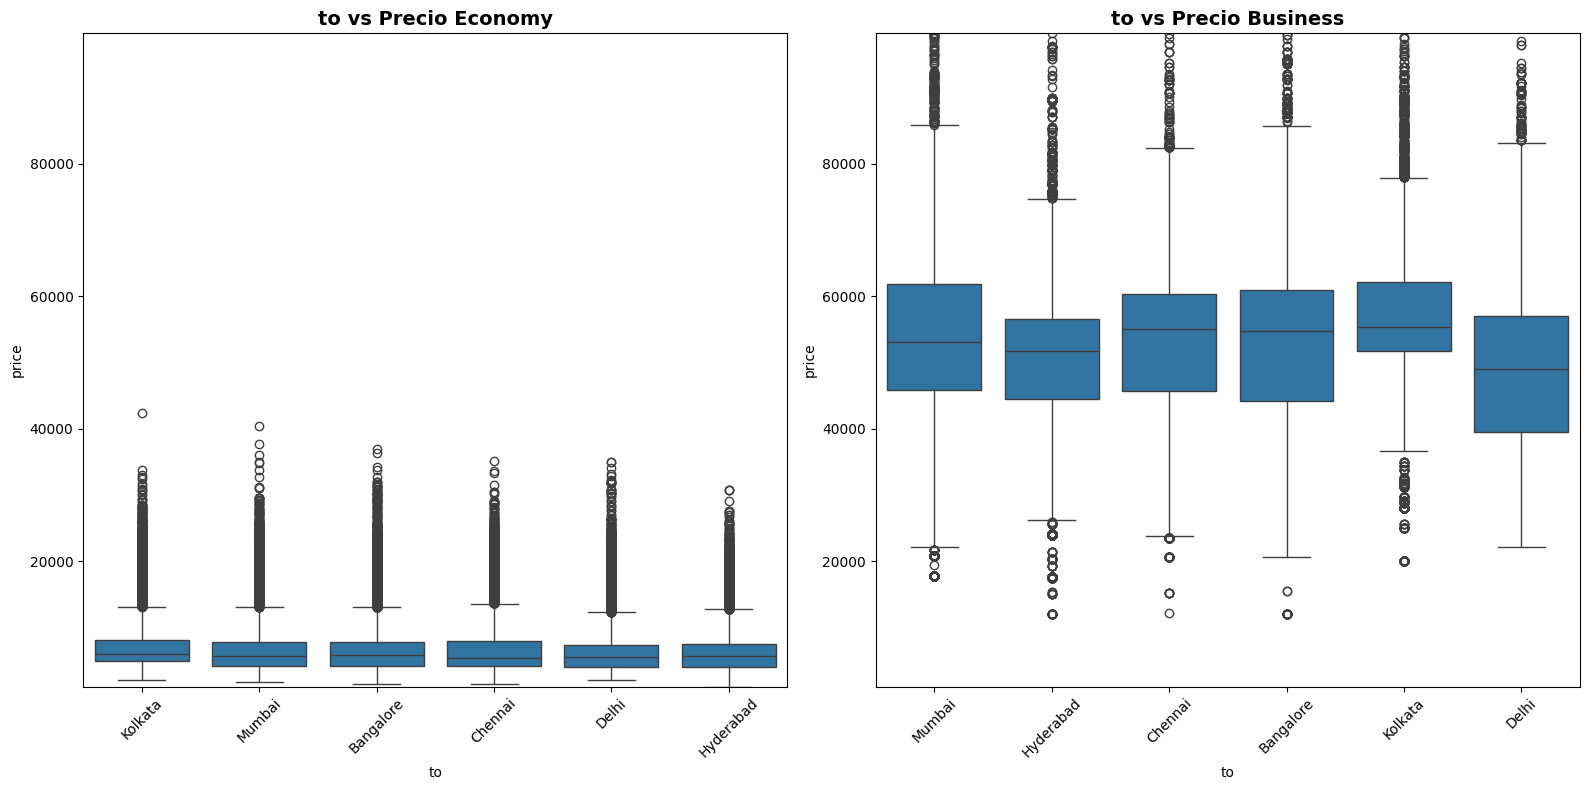

In [25]:
grafico_variables('to')

Sin importar el lugar de destino, los valores de los pasajes son similares en Economy y Business

In [26]:
df_e['to'].value_counts()

to
Delhi        40654
Mumbai       40118
Bangalore    34914
Kolkata      34777
Hyderabad    29101
Chennai      27210
Name: count, dtype: int64

In [27]:
df_b['to'].value_counts()

to
Mumbai       18970
Delhi        16686
Bangalore    16175
Kolkata      14736
Hyderabad    13666
Chennai      13146
Name: count, dtype: int64

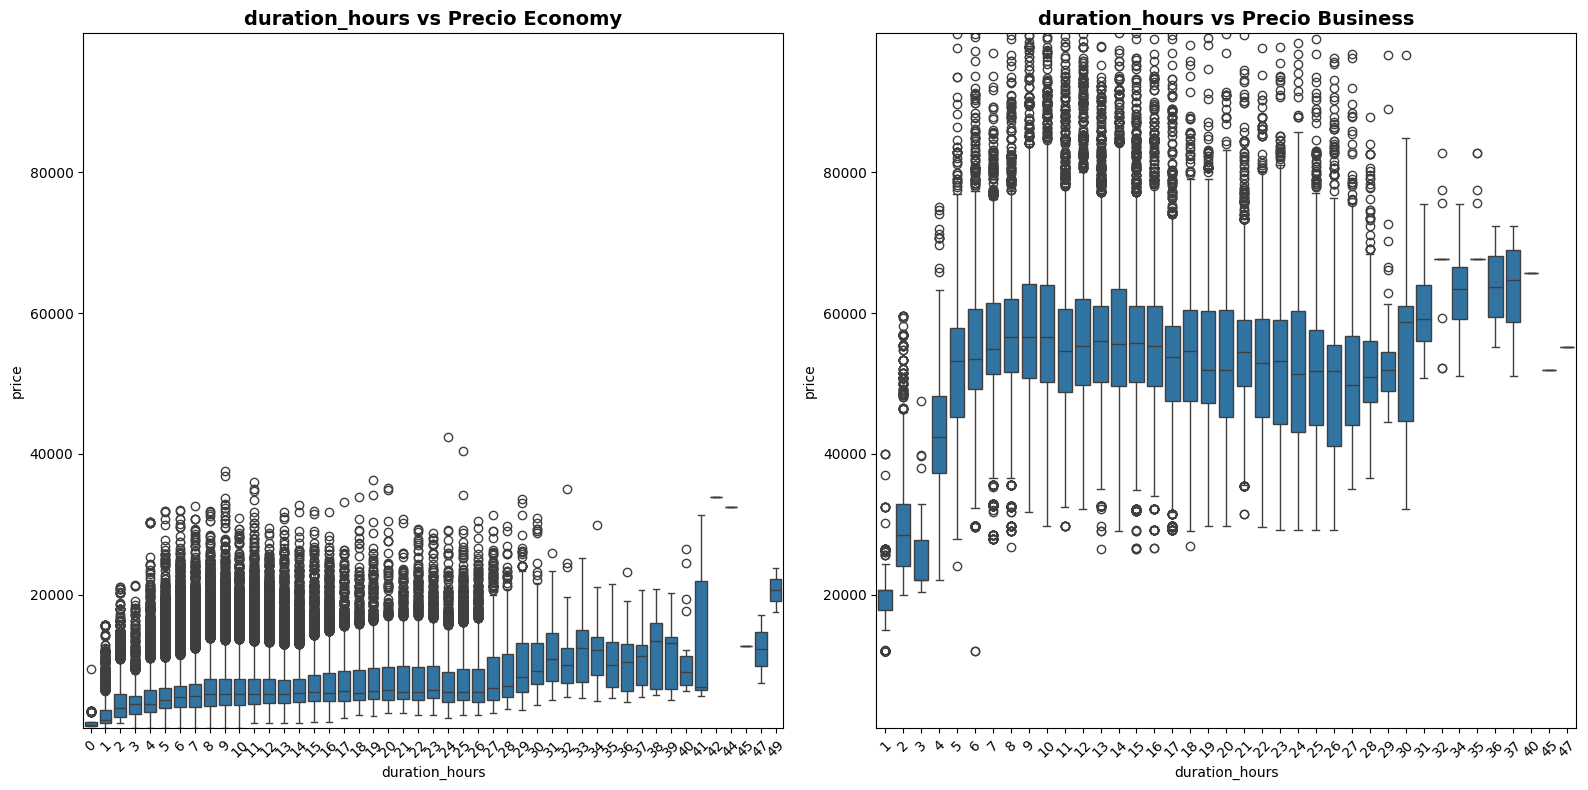

In [28]:
grafico_variables('duration_hours')

Se observa que mientras mas dura el viaje en Economy mayor es el precio del pasaje, aunque la mediana se mantiene parecida entre las 8 y 26 horas de vuelo, el rango intercuartilico si se comienza a expandir. Por otro lado, en Business, entre las 5 horas y 29 horas pareciera tener un rango de valores similares.

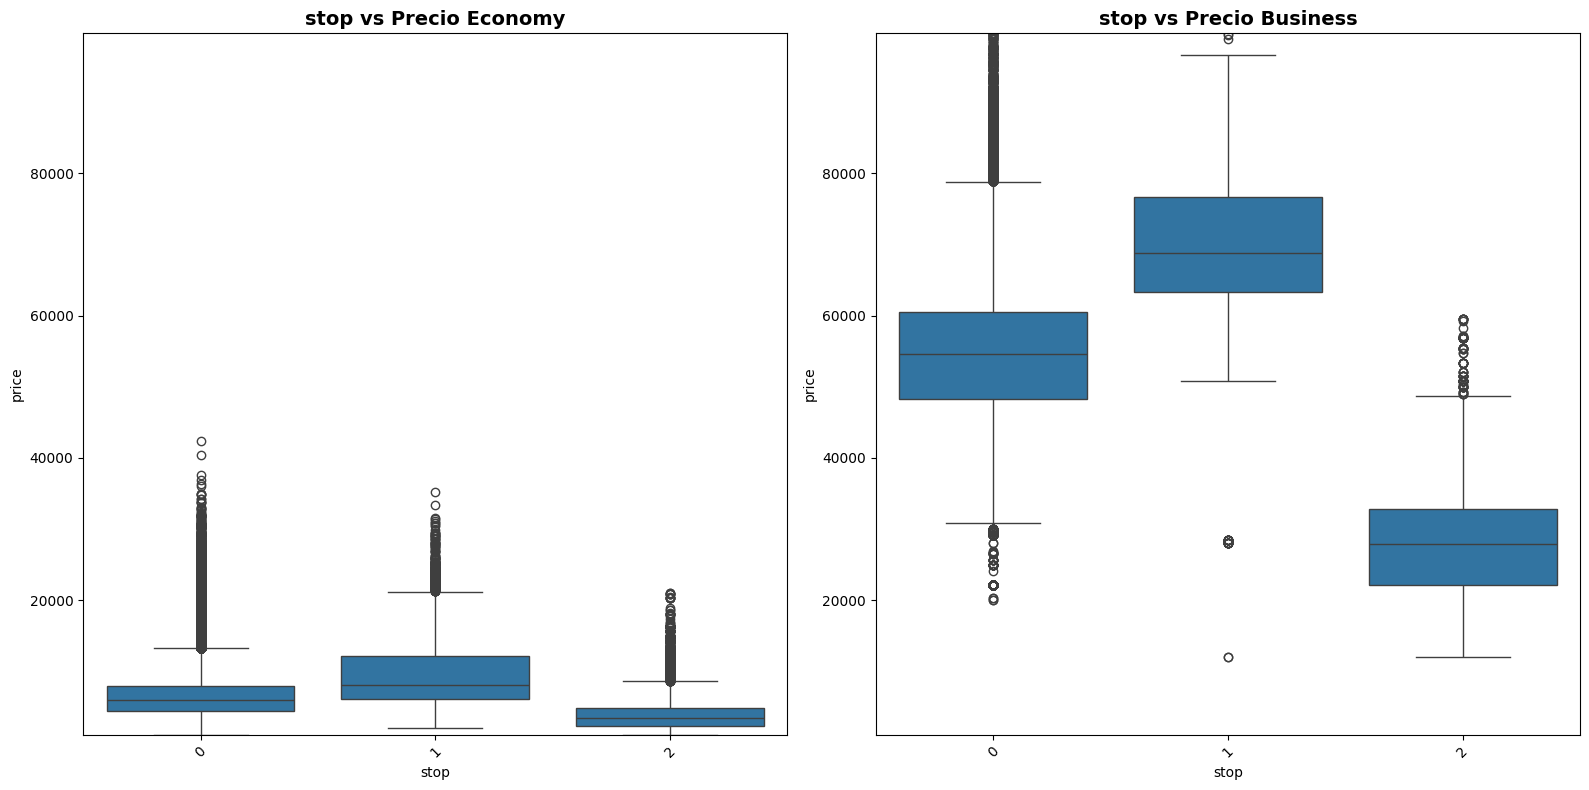

In [29]:
grafico_variables('stop')

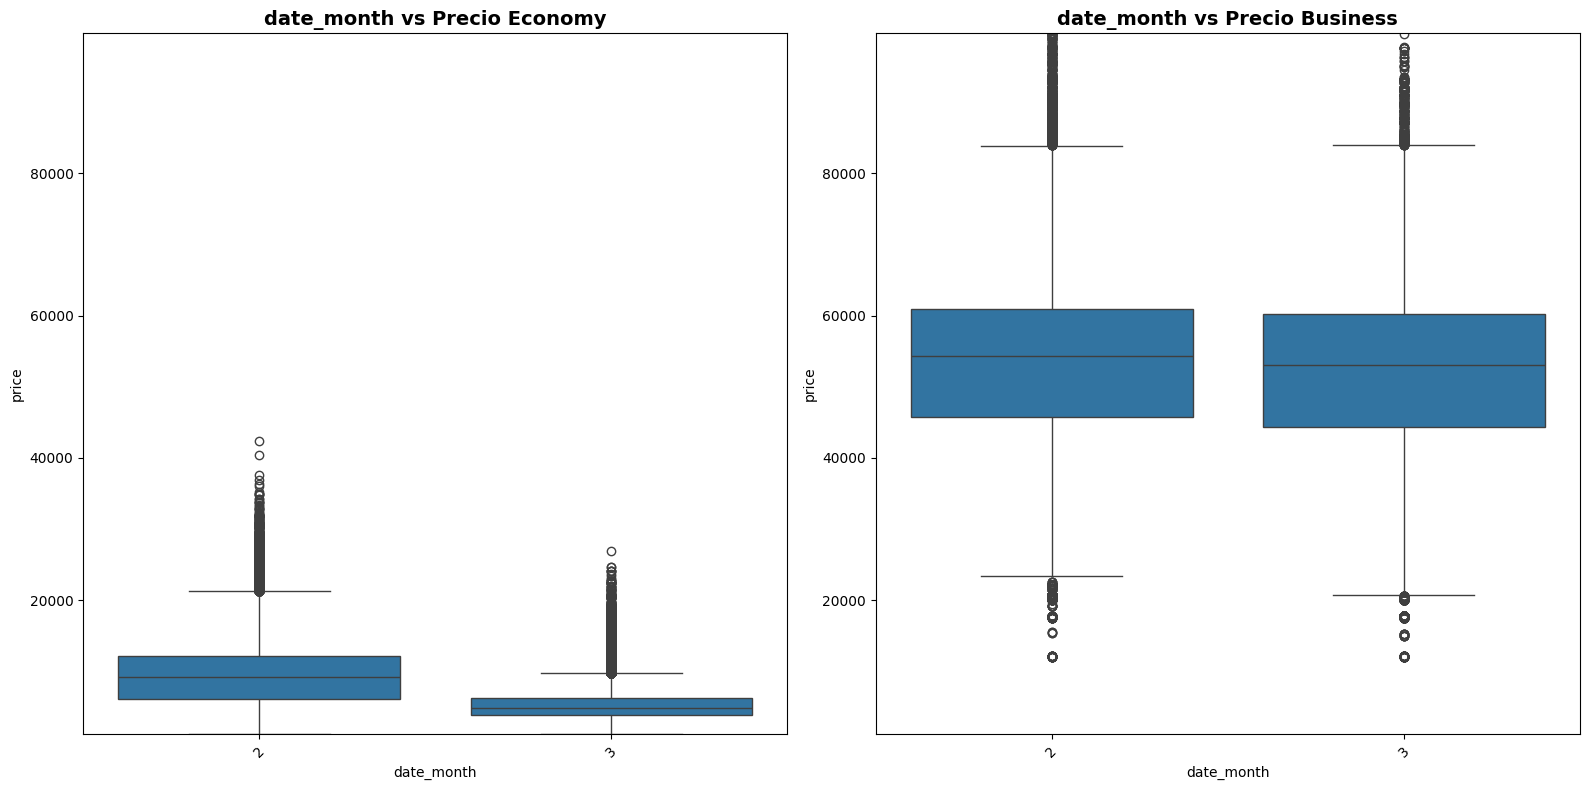

In [30]:
grafico_variables('date_month')

In [31]:
df_e['date_month'].unique()

array([2, 3], dtype=int32)

En el dataset solo hay dos meses del año, lo que no es muy representartivo para un modelo real, donde se necesitan los datos de viaje de todo el año.


2. CORRELACIÓNES:


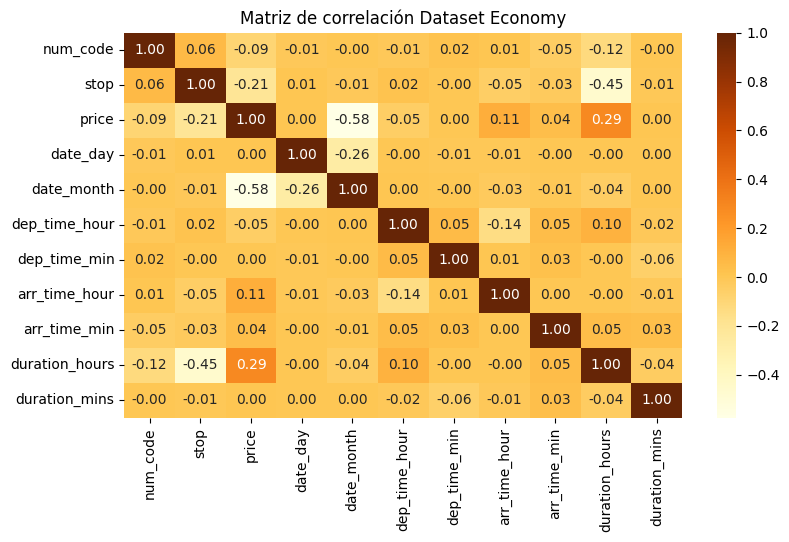

In [32]:
#columnas numericas
numeric_cols = df_e.select_dtypes(include=['float64', 'int']).columns.to_list()

#Correlacion entre variables
# Correlación después de añadir volumen
print("\n2. CORRELACIÓNES:")


plt.figure(figsize=(9, 5))
sns.heatmap(df_e[numeric_cols].corr(), annot=True, cmap='YlOrBr', fmt=".2f")
plt.title("Matriz de correlación Dataset Economy")
plt.show()


2. CORRELACIÓNES:


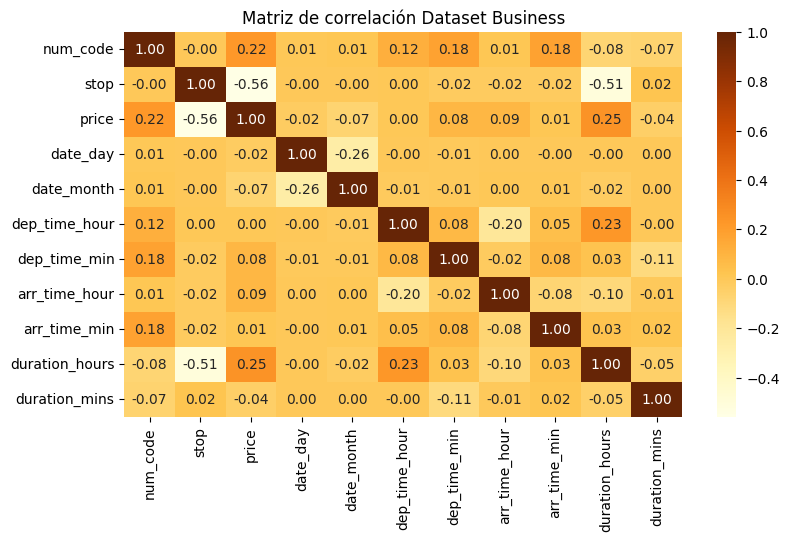

In [33]:
#columnas numericas
numeric_cols = df_b.select_dtypes(include=['float64', 'int']).columns.to_list()

#Correlacion entre variables
# Correlación después de añadir volumen
print("\n2. CORRELACIÓNES:")


plt.figure(figsize=(9, 5))
sns.heatmap(df_b[numeric_cols].corr(), annot=True, cmap='YlOrBr', fmt=".2f")
plt.title("Matriz de correlación Dataset Business")
plt.show()

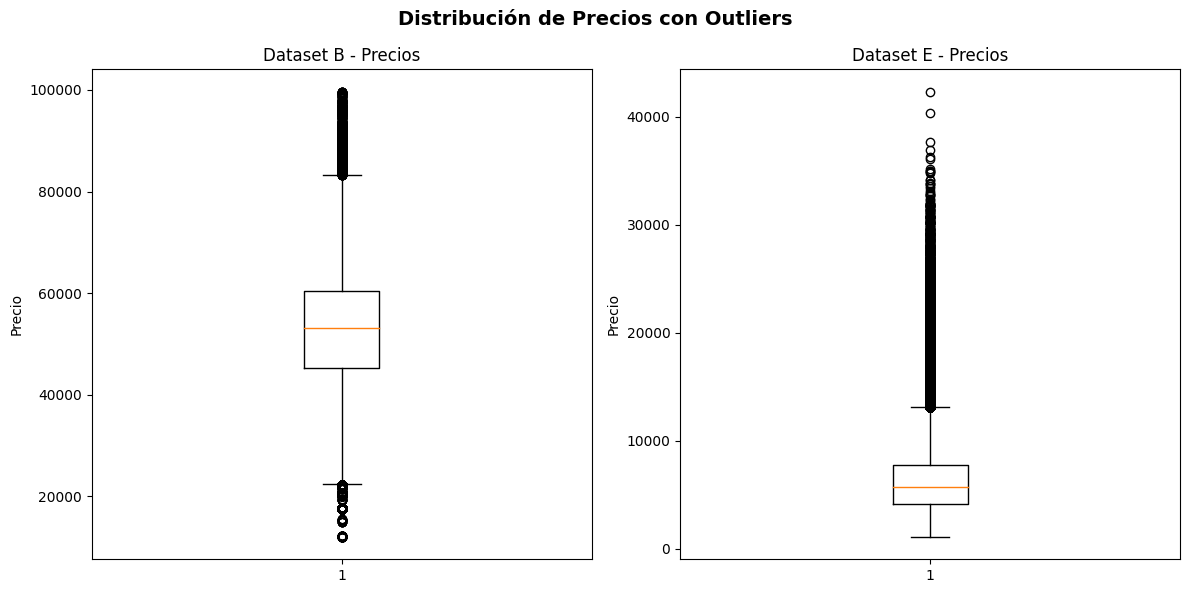

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Boxplot para df_b
ax[0].boxplot(df_b['price'].dropna())
ax[0].set_title('Dataset B - Precios')
ax[0].set_ylabel('Precio')

# Boxplot para df_e
ax[1].boxplot(df_e['price'].dropna())
ax[1].set_title('Dataset E - Precios')
ax[1].set_ylabel('Precio')

plt.suptitle('Distribución de Precios con Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Se ve que la mediana de ambos conjunto de valores estan diferentes, busines tiene precios mucho mayores lo que concuerda con la realidad. Para estos modelos, no se eliminara los outlier, para hacer modelos ajustados a todos los precios.

## División de los datos en entrenamiento y prueba.

### Se declara funcion de codificado y escalado

In [35]:
def codificado_escalado(df):
    # Definir X e y
    X = df.drop(columns = ['price','airline','num_code','date_day','dep_time_min','arr_time_hour','arr_time_min','duration_mins']) #se dejaran de lado esas variables
    
    y = df['price']
    
    # División de los datos en train y test 80/20
    X_train, X_test, y_train, y_test = train_test_split(X,
                                                        y,
                                                        test_size=0.2,
                                                        random_state = 123)
    
    # Identificación de columnas categóricas y numéricas de forma automática
    cat_cols = X_train.select_dtypes(include=['object']).columns.to_list()
    numeric_cols = X_train.select_dtypes(include=['float64', 'int']).columns.to_list()
    
    # Definimos el preprocesador para ambas transformaciones 
    preprocessor = ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
            ('scaler', StandardScaler(), numeric_cols)
        ]
    )
    
    # Ajustamos y transformamos los datos de entrenamiento y solo transformamos los de test
    X_train_prep = preprocessor.fit_transform(X_train)
    X_test_prep  = preprocessor.transform(X_test)
    
    # Convertir el output del ColumnTransformer en dataframe y añadir el nombre de las columnas
    labels = []
    
    # Extracción de nombres de columnas categóricas codificadas y numéricas
    encoded_cat = preprocessor.named_transformers_['onehot'].get_feature_names_out(cat_cols)
    labels.extend(encoded_cat)
    labels = np.concatenate([encoded_cat, numeric_cols])  # Primero categóricas, luego numericas
    
    # Conversión a DataFrame con el orden correcto de columnas
    X_train_prep = pd.DataFrame(X_train_prep, columns=labels)
    X_test_prep  = pd.DataFrame(X_test_prep, columns=labels)
    
    return X_train_prep, X_test_prep, X_train, X_test, y_train, y_test

In [36]:
#uso de la funcion para codificar y escalar para ambos datasets
X_b_train_prep, X_b_test_prep, X_b_train, X_b_test, y_b_train, y_b_test = codificado_escalado(df_b)
X_e_train_prep, X_e_test_prep, X_e_train, X_e_test, y_e_train, y_e_test = codificado_escalado(df_e)

## MODELADO: EL ÁRBOL DE DECISIÓN (BASELINE)

Empezamos con un solo árbol para tener una referencia.

In [37]:
# Función de Métricas
def report_metrics(y_true, y_pred, set_name):
    """
    Imprime las principales métricas de evaluación de un modelo de regresión.
    y_true : valores reales
    y_pred : valores predichos
    set_name: 'Train' o 'Test' para identificar el conjunto
    """

    # Cálculo de métricas básicas
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # Crear diccionario con valores formateados
    metrics = {
        "R²": f"{r2:.3f}",
        "MAE": f"{mae:.2f}",
        "MSE": f"{mse:.2f}",
        "RMSE": f"{rmse:.2f}"
    }

     # Convertir a DataFrame
    metrics_df = pd.DataFrame({
        "Métrica": list(metrics.keys()), 
        "Valor": list(metrics.values())
    })


       # Imprimir resultados
    print("=" * 50)
    print(f"MÉTRICAS DEL MODELO {set_name}")
    print("=" * 50)
    print(metrics_df.round(4))
    print("=" * 50)
    
    return metrics_df

In [38]:
# Entrenar un modelo de arbol de decision sin modificar hiperparametros
tree_model = DecisionTreeRegressor(random_state=42)

In [39]:
#Entrenar modelo Business y Economy
tree_model.fit(X_b_train_prep, y_b_train)

DecisionTreeRegressor(random_state=42)

In [40]:
# Evaluar modelo business con datos de test
y_pred_tree = tree_model.predict(X_b_test_prep)
m_tree_b_test = report_metrics(y_b_test, y_pred_tree, "Decision Tree (Simple) Business TEST")

# Evaluar modelo business con datos de train
y_pred_tree = tree_model.predict(X_b_train_prep)
m_tree_b_train = report_metrics(y_b_train, y_pred_tree, "Decision Tree (Simple Business) TRAIN")

MÉTRICAS DEL MODELO Decision Tree (Simple) Business TEST
  Métrica        Valor
0      R²        0.857
1     MAE      2604.52
2     MSE  23451582.21
3    RMSE      4842.68
MÉTRICAS DEL MODELO Decision Tree (Simple Business) TRAIN
  Métrica        Valor
0      R²        0.883
1     MAE      2341.52
2     MSE  19393911.17
3    RMSE      4403.85


El modelo de arbol con parametros por defecto indica que explixa un 88% de los datos elm dataset business, con un error promedio de $4,843, por prediccion. 

In [41]:
#Entrenar modelo Economy
tree_model.fit(X_e_train_prep, y_e_train)

DecisionTreeRegressor(random_state=42)

In [42]:
# Evaluar modelo economy con datos de test
y_pred_tree = tree_model.predict(X_e_test_prep)
m_tree_e_test = report_metrics(y_e_test, y_pred_tree, "Decision Tree (Simple) Economy Test")

# Evaluar modelo economy con datos de train
y_pred_tree = tree_model.predict(X_e_train_prep)
m_tree_e_train = report_metrics(y_e_train, y_pred_tree, "Decision Tree (Simple) Economy Train")

MÉTRICAS DEL MODELO Decision Tree (Simple) Economy Test
  Métrica       Valor
0      R²       0.694
1     MAE     1072.88
2     MSE  4238225.95
3    RMSE     2058.70
MÉTRICAS DEL MODELO Decision Tree (Simple) Economy Train
  Métrica       Valor
0      R²       0.765
1     MAE      951.61
2     MSE  3307560.82
3    RMSE     1818.67


Mientras, que en el dataset economy explica solo un 69% de los datos pero con un error promedio de $2,059, lo cual lo hace un modelo menos explicativo de los datos pero tambien con erroes menores por prediccion.

### Optimización de Hiperparámetros

Se optimiza el árbol de decisión ajustando:

* `max_depth`: controla la complejidad del árbol.
* `max_features`: define cuántos atributos se usan en cada división.

La selección se realiza con **GridSearchCV** y validación cruzada de 5 folds.

In [43]:
# Definir la grilla de hiperparámetros
param_grid = {
    'max_features': ['sqrt', 'log2'],  # raíz cuadrada, log2, 50%, todos los atributos posibles
    'max_depth': np.arange(1, 33)                           # profundidad de 1 a 32
}


# Búsqueda por validación cruzada
grid_model_tree = GridSearchCV(DecisionTreeRegressor(random_state=1234),
                          param_grid,
                          cv=5,
                          verbose=1,
                          n_jobs=-1)

In [44]:
# Entrenar modelo con la grilla Business
grid_model_tree.fit(X_b_train_prep, y_b_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=1234),
             n_jobs=-1,
             param_grid={'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]),
                         'max_features': ['sqrt', 'log2']},
             verbose=1)

In [45]:
# Evaluar modelo business con datos de test
y_pred_grid_tree = grid_model_tree.predict(X_b_test_prep)
m_grid_tree_b_test = report_metrics(y_b_test, y_pred_grid_tree, "Grid Decision Tree TEST Business")

# Evaluar modelo business con datos de train (para verificar overfitting)
y_pred_grid_tree = grid_model_tree.predict(X_b_train_prep)
m_grid_tree_b_train = report_metrics(y_b_train, y_pred_grid_tree, "Grid Decision Tree TRAIN Business")

MÉTRICAS DEL MODELO Grid Decision Tree TEST Business
  Métrica        Valor
0      R²        0.857
1     MAE      2607.09
2     MSE  23493082.74
3    RMSE      4846.97
MÉTRICAS DEL MODELO Grid Decision Tree TRAIN Business
  Métrica        Valor
0      R²        0.883
1     MAE      2344.10
2     MSE  19413930.30
3    RMSE      4406.12


Este modelo tiene una explicabilidad mucho mayor, 88%, aunque el error promedio por prediccion sigue siendo sobre los $4000 dolares.

In [46]:
# Entrenar modelo con la grilla Economy
grid_model_tree.fit(X_e_train_prep, y_e_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=1234),
             n_jobs=-1,
             param_grid={'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]),
                         'max_features': ['sqrt', 'log2']},
             verbose=1)

In [47]:
# Evaluar modelo business con datos de test
y_pred_grid_tree = grid_model_tree.predict(X_e_test_prep)
m_grid_tree_e_test = report_metrics(y_e_test, y_pred_grid_tree, "Grid Decision Tree TEST Economy")

# Evaluar modelo economy con datos de train (para verificar overfitting)
y_pred_grid_tree = grid_model_tree.predict(X_e_train_prep)
m_grid_tree_e_train = report_metrics(y_e_train, y_pred_grid_tree, "Grid Decision Tree TRAIN Economy")

MÉTRICAS DEL MODELO Grid Decision Tree TEST Economy
  Métrica       Valor
0      R²       0.696
1     MAE     1072.51
2     MSE  4214941.47
3    RMSE     2053.03
MÉTRICAS DEL MODELO Grid Decision Tree TRAIN Economy
  Métrica       Valor
0      R²       0.764
1     MAE      951.86
2     MSE  3310531.87
3    RMSE     1819.49


Este modelo tiene optimizado por GridSearch tiene mejores resultados en el dataset de Business.

## MODELADO: REGRESION Lineal

In [48]:
# Crear y entrenar el modelo con GridSearchCV
model_lr = LinearRegression()

In [49]:
#Entrenar modelo Business y Economy
model_lr.fit(X_b_train_prep, y_b_train)

LinearRegression()

In [50]:
# Evaluar modelo business con datos de test
y_pred_b_lr = model_lr.predict(X_b_test_prep)
m_lr_b_test = report_metrics(y_b_test, y_pred_b_lr, "Linear Regression (Simple) Test Business")

# Evaluar modelo business con datos de test
y_pred_b_lr = model_lr.predict(X_b_train_prep)
m_lr_b_train = report_metrics(y_b_train, y_pred_b_lr, "Linear Regression (Simple) Train Business")

MÉTRICAS DEL MODELO Linear Regression (Simple) Test Business
  Métrica        Valor
0      R²        0.476
1     MAE      7025.78
2     MSE  86158093.12
3    RMSE      9282.14
MÉTRICAS DEL MODELO Linear Regression (Simple) Train Business
  Métrica        Valor
0      R²        0.473
1     MAE      7084.92
2     MSE  87158937.16
3    RMSE      9335.90


In [51]:
#Entrenar modelo Economy
model_lr.fit(X_e_train_prep, y_e_train)

LinearRegression()

In [52]:
# Evaluar modelo business con datos de test
y_pred_e_lr = model_lr.predict(X_e_test_prep)
m_lr_e_test = report_metrics(y_e_test, y_pred_e_lr, "Linear Regression (Simple) Train Economy")

# Evaluar modelo economy con datos de train
y_pred_e_lr = model_lr.predict(X_e_train_prep)
m_lr_e_train = report_metrics(y_e_train, y_pred_e_lr, "Linear Regression (Simple) Test Economy")

MÉTRICAS DEL MODELO Linear Regression (Simple) Train Economy
  Métrica       Valor
0      R²       0.492
1     MAE     1777.47
2     MSE  7049742.66
3    RMSE     2655.14
MÉTRICAS DEL MODELO Linear Regression (Simple) Test Economy
  Métrica       Valor
0      R²       0.493
1     MAE     1790.90
2     MSE  7129751.63
3    RMSE     2670.16


In [53]:
### Optimización con Grid Search 

In [54]:
# 1. Definir Grilla
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False],  # Solo coeficientes positivos
    'n_jobs': [-1, 1, 2]  # Paralelización
}

# 2. Configurar GridSearch
model_lr = LinearRegression()
grid_lr = GridSearchCV(
    model_lr, 
    param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

In [55]:
# Entrenar modelo con la grilla Business
grid_lr.fit(X_b_train_prep, y_b_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False], 'n_jobs': [-1, 1, 2],
                         'positive': [True, False]},
             scoring='r2')

In [56]:
# Evaluar modelo business con datos de test
y_pred_grid_lr = grid_lr.predict(X_b_test_prep)
m_grid_lr_b_train = report_metrics(y_b_test, y_pred_grid_lr, "Grid Linear Regresion Business Test")

# Evaluar modelo business con datos de train
y_pred_grid_lr = grid_lr.predict(X_b_train_prep)
m_grid_lr_b_test = report_metrics(y_b_train, y_pred_grid_lr, "Grid Linear Regresion Business Train")

MÉTRICAS DEL MODELO Grid Linear Regresion Business Test
  Métrica        Valor
0      R²        0.476
1     MAE      7025.78
2     MSE  86158093.12
3    RMSE      9282.14
MÉTRICAS DEL MODELO Grid Linear Regresion Business Train
  Métrica        Valor
0      R²        0.473
1     MAE      7084.92
2     MSE  87158937.16
3    RMSE      9335.90


In [57]:
# Entrenar modelo con la grilla Economy
grid_lr.fit(X_e_train_prep, y_e_train)

# Evaluar modelo economy con datos de test
y_pred_grid_lr = grid_lr.predict(X_e_test_prep)
m_grid_lr_e_test = report_metrics(y_e_test, y_pred_grid_lr, "Grid Linear Regresion")

# Evaluar modelo economy con datos de train
y_pred_grid_lr = grid_lr.predict(X_e_train_prep)
m_grid_lr_e_train = report_metrics(y_e_train, y_pred_grid_lr, "Grid Linear Regresion")

MÉTRICAS DEL MODELO Grid Linear Regresion
  Métrica       Valor
0      R²       0.492
1     MAE     1777.47
2     MSE  7049742.66
3    RMSE     2655.14
MÉTRICAS DEL MODELO Grid Linear Regresion
  Métrica       Valor
0      R²       0.493
1     MAE     1790.90
2     MSE  7129751.63
3    RMSE     2670.16


El modelo de regresion lineal solo explica un 50% de los datos. Y con un error promedio de predicción de 9,282 para Business y 2,655 para Economy. Un modelo de regresion lineal no es un buen predictor hasta el momento. Para mejorarlo quizas se podrían elegir variables mas significativas para el modelo

## MODELADO: RANDOM FOREST

In [58]:
# Creacion del modelo
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Entrenar Random Forest Business
rf_model.fit(X_b_train_prep, y_b_train)

# Evaluar con datos test
y_pred_rf = rf_model.predict(X_b_test_prep)
m_rf_b_test = report_metrics(y_b_test, y_pred_rf, "Random Forest BUSINESS TEST")

# Evaluar con datos train
y_pred_rf = rf_model.predict(X_b_train_prep)
m_rf_b_train = report_metrics(y_b_train, y_pred_rf, "Random Forest (BUSINESS TRAIN")

MÉTRICAS DEL MODELO Random Forest BUSINESS TEST
  Métrica        Valor
0      R²        0.858
1     MAE      2615.39
2     MSE  23319361.03
3    RMSE      4829.01
MÉTRICAS DEL MODELO Random Forest (BUSINESS TRAIN
  Métrica        Valor
0      R²        0.882
1     MAE      2369.14
2     MSE  19528267.33
3    RMSE      4419.08


In [59]:
# Entrenar Random Forest Economy
rf_model.fit(X_e_train_prep, y_e_train)

# Evaluar con datos test
y_pred_rf = rf_model.predict(X_e_test_prep)
m_rf_e_test = report_metrics(y_e_test, y_pred_rf, "Random Forest Economy Test")

# Evaluar con datos train
y_pred_rf = rf_model.predict(X_e_train_prep)
m_rf_e_train = report_metrics(y_e_train, y_pred_rf, "Random Forest Economy train")

MÉTRICAS DEL MODELO Random Forest Economy Test
  Métrica       Valor
0      R²       0.702
1     MAE     1070.25
2     MSE  4138099.49
3    RMSE     2034.23
MÉTRICAS DEL MODELO Random Forest Economy train
  Métrica       Valor
0      R²       0.763
1     MAE      962.20
2     MSE  3331092.75
3    RMSE     1825.13


El modelo random forest es es mejor con el dataset de Business, aunque el RMSE es mayor. De todas formas, sigue siendo un modelo bastante bueno. Con bajo error, cerca de los 2000 mil dolares


### Optimización con Grid Search Random Forest

In [60]:
# 1. Definir Grilla
param_grid = {
    'n_estimators': [100, 150, 200] , # range(20, 201, 20)
    'max_depth': [10, 20, 30], # np.arange(1, 33)  
    'max_features': ['log2', 'sqrt'] # sqrt es clásico, 0.5 usa el 50% de las variables
}

# 2. Configurar GridSearch
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error', # Buscamos minimizar RMSE
    verbose=1,
    n_jobs=-1
)

In [62]:
# Entrenar modelo con la grilla Business
grid_rf.fit(X_b_train_prep, y_b_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'max_features': ['log2', 'sqrt'],
                         'n_estimators': [100, 150, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [63]:
# Evaluar modelo business con datos de test
y_pred_grid_rf = grid_rf.predict(X_b_test_prep)
m_grid_rf_b_test = report_metrics(y_b_test, y_pred_grid_rf, "Grid Random Forest Business Train")

# Evaluar modelo business con datos de test
y_pred_grid_rf = grid_rf.predict(X_b_train_prep)
m_grid_rf_b_train = report_metrics(y_b_train, y_pred_grid_rf, "Grid Random Forest Business Test")

MÉTRICAS DEL MODELO Grid Random Forest Business Train
  Métrica        Valor
0      R²        0.858
1     MAE      2625.42
2     MSE  23338718.21
3    RMSE      4831.02
MÉTRICAS DEL MODELO Grid Random Forest Business Test
  Métrica        Valor
0      R²        0.882
1     MAE      2371.44
2     MSE  19518512.91
3    RMSE      4417.98


In [64]:
# Entrenar modelo con la grilla Economy
grid_rf.fit(X_e_train_prep, y_e_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x106d7f7e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ml-env/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/ml-env/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/ml-env/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/opt/anaconda3/envs/ml-env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x1061cb7e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ml-env/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/ml-env/li

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'max_features': ['log2', 'sqrt'],
                         'n_estimators': [100, 150, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [65]:
# Evaluar modelo economy con datos de test
y_pred_grid_rf = grid_rf.predict(X_e_test_prep)
m_grid_rf_e_test = report_metrics(y_e_test, y_pred_grid_rf, "Grid Random Forest Economy Test")

# Evaluar modelo economy con datos de test
y_pred_grid_rf = grid_rf.predict(X_e_train_prep)
m_grid_rf_e_train = report_metrics(y_e_train, y_pred_grid_rf, "Grid Random Forest Economy Train")

MÉTRICAS DEL MODELO Grid Random Forest Economy Test
  Métrica       Valor
0      R²       0.708
1     MAE     1085.73
2     MSE  4052079.50
3    RMSE     2012.98
MÉTRICAS DEL MODELO Grid Random Forest Economy Train
  Métrica       Valor
0      R²       0.754
1     MAE     1003.94
2     MSE  3451120.72
3    RMSE     1857.72


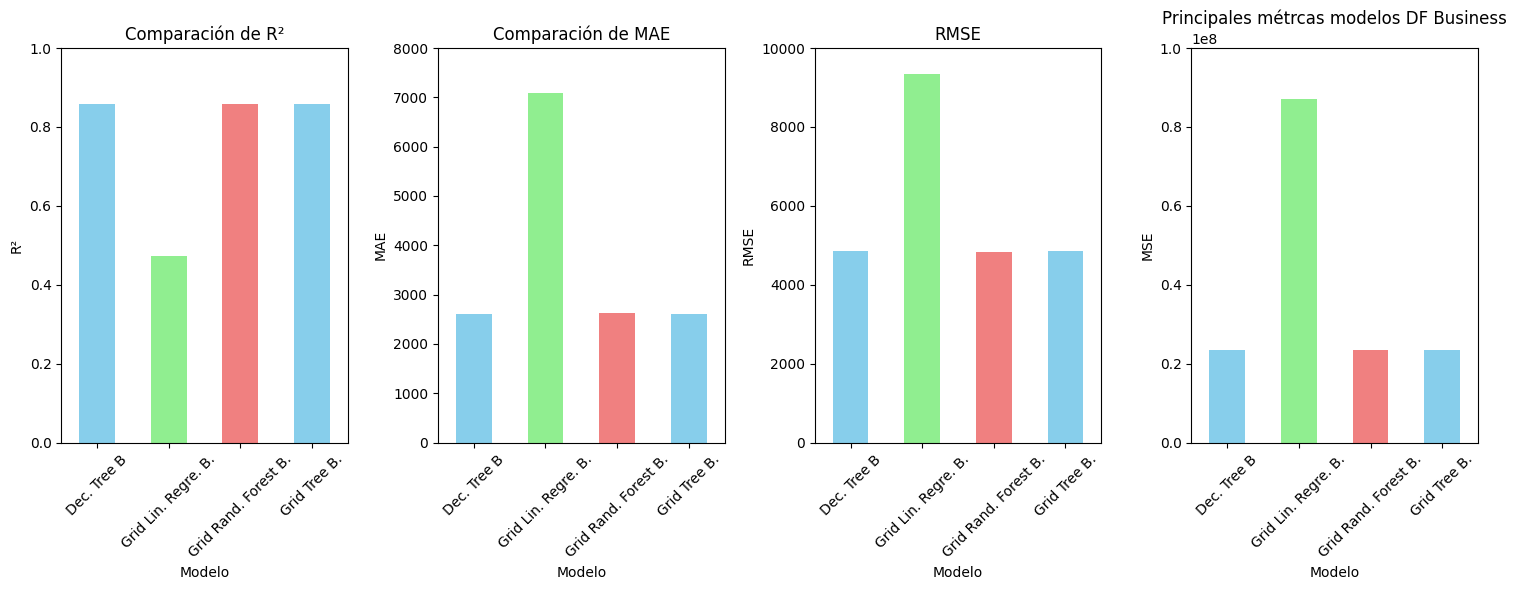

In [67]:
# Configurar el estilo
plt.style.use('default')
sns.set_palette("husl")

# Crear un DataFrame combinado
metricas_combinadas_b = pd.concat([
    m_tree_b_test.assign(Modelo='Dec. Tree B'),
    m_grid_tree_b_test.assign(Modelo='Grid Tree B.'),
    m_grid_lr_b_test.assign(Modelo='Grid Lin. Regre. B.'),
    m_grid_rf_b_test.assign(Modelo='Grid Rand. Forest B.')
], ignore_index=True)

# Pivotear el DataFrame para tener métricas como columnas
df_pivot = metricas_combinadas_b.pivot(index='Modelo', columns='Métrica', values='Valor')

# Crear el gráfico de barras comparativo
fig, axes = plt.subplots(1, 4, figsize=(15, 6))

# Gráfico para r2
df_pivot['R²'].astype(float).plot(kind='bar', ax=axes[0], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[0].set_title('Comparación de R²')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico para MAE
df_pivot['MAE'].astype(float).plot(kind='bar', ax=axes[1], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[1].set_title('Comparación de MAE')
axes[1].set_ylabel('MAE')
axes[1].set_ylim(0, 8000)
axes[1].tick_params(axis='x', rotation=45)

# Gráfico para RMSE	
df_pivot['RMSE'].astype(float).plot(kind='bar', ax=axes[2], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[2].set_title('RMSE')
axes[2].set_ylabel('RMSE')
axes[2].set_ylim(0, 10000)
axes[2].tick_params(axis='x', rotation=45)

# Gráfico para MSE
df_pivot['MSE'].astype(float).plot(kind='bar', ax=axes[3], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[3].set_title('Comparación de MSE')
axes[3].set_ylabel('MSE')
axes[3].set_ylim(0, 100000000)
axes[3].tick_params(axis='x', rotation=45)

plt.title('Principales métrcas modelos DF Business')
plt.tight_layout()
plt.show()

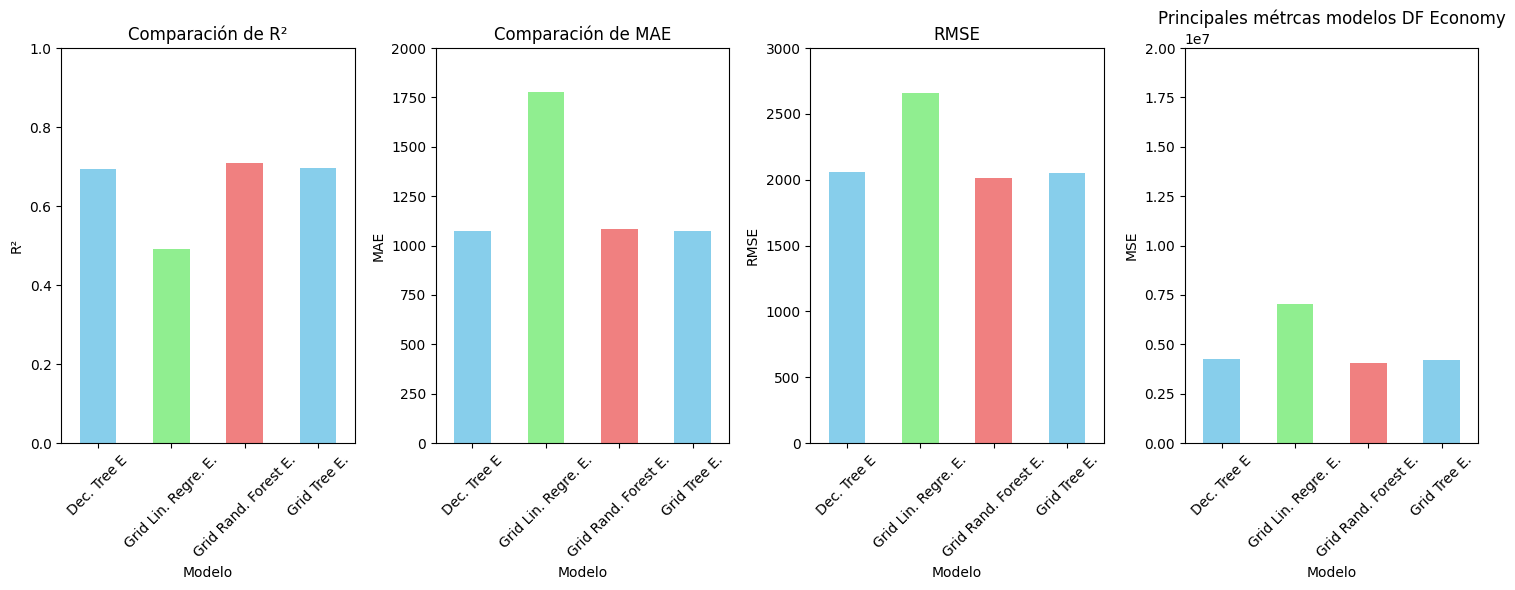

In [68]:
# Configurar el estilo
plt.style.use('default')
sns.set_palette("husl")

# Crear un DataFrame combinado
metricas_combinadas_e = pd.concat([
    m_tree_e_test.assign(Modelo='Dec. Tree E'),
    m_grid_tree_e_test.assign(Modelo='Grid Tree E.'),
    m_grid_lr_e_test.assign(Modelo='Grid Lin. Regre. E.'),
    m_grid_rf_e_test.assign(Modelo='Grid Rand. Forest E.')
], ignore_index=True)

# Pivotear el DataFrame para tener métricas como columnas
df_pivot = metricas_combinadas_e.pivot(index='Modelo', columns='Métrica', values='Valor')

# Crear el gráfico de barras comparativo
fig, axes = plt.subplots(1, 4, figsize=(15, 6))

# Gráfico para r2
df_pivot['R²'].astype(float).plot(kind='bar', ax=axes[0], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[0].set_title('Comparación de R²')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico para MAE
df_pivot['MAE'].astype(float).plot(kind='bar', ax=axes[1], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[1].set_title('Comparación de MAE')
axes[1].set_ylabel('MAE')
axes[1].set_ylim(0, 2000)
axes[1].tick_params(axis='x', rotation=45)

# Gráfico para RMSE	
df_pivot['RMSE'].astype(float).plot(kind='bar', ax=axes[2], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[2].set_title('RMSE')
axes[2].set_ylabel('RMSE')
axes[2].set_ylim(0, 3000)
axes[2].tick_params(axis='x', rotation=45)

# Gráfico para MSE
df_pivot['MSE'].astype(float).plot(kind='bar', ax=axes[3], color=['skyblue', 'lightgreen', 'lightcoral'])
axes[3].set_title('Comparación de MSE')
axes[3].set_ylabel('MSE')
axes[3].set_ylim(0, 20000000)
axes[3].tick_params(axis='x', rotation=45)

plt.title('Principales métrcas modelos DF Economy')
plt.tight_layout()
plt.show()

### Análisis de Resultados - Dataset Business:

Los modelos de árboles (Decision Tree, Random Forest) tienen un R² de alrededor de 0.85-0.86, esto indica que explican aproximadamente el 85% de la variabilidad en los precios de los vuelos. Esto es bastante bueno para un problema de predicción de precios.

El Random Forest Grid es el que tiene mejor R² (0.858) y menor MSE (23,338,718), aunque no es mucha la diferencia respecto al Decision Tree básico. Se podría decir que ambos modelos de árboles están teniendo un rendimiento similar, a pesar de que el GridSearch ha utilizado más recursos.

La Regresión Lineal con Grid Search está dando resultados bajos: R² de solo 0.47 y RMSE de ~2,655. Esto confirma que la relación entre las variables y el precio no es lineal simple, y por eso los modelos basados en árboles funcionan mejor.

El RMSE de ~4,800-4,900 en los mejores modelos nos dice que los errores más grandes (outliers en las predicciones) están en ese rango.

Quizás sea recomendable eliminar outliers para mejorar las predicciones en rangos donde están la mayoria de los precios de los vuelos.

### Conclusión del dataset Business:
Para el dataset Business, Random Forest con Grid Search es el mejor modelo, aunque prácticamente igual al Decision Tree básico. La Regresión Lineal no es adecuada para este problema, probablemente porque hay relaciones no lineales entre las variables que afectan el precio.

Los modelos están explicando bien los patrones generales (85% de varianza explicada), pero todavía hay margen para mejorar, especialmente en reducir el error absoluto promedio (MAE), quizás eliminando outliers.



### Análisis de Resultados - Dataset Economy:

Los modelos de árboles Decision Tree, Random Forest tienen un R² que varía entre 0.69-0.71, esto indica que explican aproximadamente el 70% de la variabilidad en los precios de los vuelos económicos. Aunque es menor que en Business (85%), sigue siendo un resultado aceptable para predicción de precios.

El Random Forest Grid es el que tiene mejor R² (0.708) y menores errores MSE (4,052,079) y RMSE	(2053.03), superando ligeramente al Decision Tree básico. La diferencia entre ambos modelos de árbol es pequeña.

La Regresión Lineal con Grid Search tampoco da buenos resultados: R² de solo 0.49 y MAE de ~1,777. Esto confirma el patrón visto en en el dataset de Business: la relación precio-variables quizás no es lineal, y los modelos basados en árboles son más apropiados.

En general los erroes, de la prediciones en Economy son menores, indicando que los modelos se equivocan menos, o que los precios tienen menor variabilidad.

### Comparación Business vs Economy:

Business: Mayor R² (0.85 vs 0.71) pero mayor error absoluto (MAE ~2,600 vs ~1,075)

Economy: Menor R² pero menores errores.

En Ambos datasets, Random Forest optimizado es el mejor performer, y la regresion lineal funciona mal, lo que sugiere que las variables no tienen relaciones lineales.

### Conclusión Final:

Para el dataset Economy, Random Forest con Grid Search es el mejor modelo, aunque con poca diferencia sobre el Decision Tree básico. Los precios económicos muestran menor capacidad predictiva (70% vs 85% de varianza explicada) pero errores absolutos más bajos.

La menor performance relativa (R² más bajo) podría deberse a que los vuelos económicos tienen más variabilidad impredecible en precios, quizás por mayores fluctuaciones de oferta-demanda. Es recomendable analizar si al eliminar outliers mejoran aún más las métricas, especialmente el R².

In [69]:
metricas_combinadas_b

,Métrica,Valor,Modelo
0,R²,0.857,Dec. Tree B
1,MAE,2604.52,Dec. Tree B
2,MSE,23451582.21,Dec. Tree B
3,RMSE,4842.68,Dec. Tree B
4,R²,0.857,Grid Tree B.
5,MAE,2607.09,Grid Tree B.
6,MSE,23493082.74,Grid Tree B.
7,RMSE,4846.97,Grid Tree B.
8,R²,0.473,Grid Lin. Regre. B.
9,MAE,7084.92,Grid Lin. Regre. B.


In [70]:
metricas_combinadas_e

,Métrica,Valor,Modelo
0,R²,0.694,Dec. Tree E
1,MAE,1072.88,Dec. Tree E
2,MSE,4238225.95,Dec. Tree E
3,RMSE,2058.70,Dec. Tree E
4,R²,0.696,Grid Tree E.
5,MAE,1072.51,Grid Tree E.
6,MSE,4214941.47,Grid Tree E.
7,RMSE,2053.03,Grid Tree E.
8,R²,0.492,Grid Lin. Regre. E.
9,MAE,1777.47,Grid Lin. Regre. E.
